# PINNsFormer + HARMONIC-4：Navier–Stokes × 3 Seeds

本 notebook **只运行 HARMONIC-4**，不重复运行 Adam / ConFIG / M-ConFIG / AutoBalance baseline；输出口径用于直接加入当前横向总表。

四个 optimization objectives 保持不变：

$$
L_{u,\mathrm{data}},\quad L_{v,\mathrm{data}},\quad L_{f_u},\quad L_{f_v}.
$$

HARMONIC 依据 ICLR 2026 论文 *Harmonized Cone for Feasible and Non-conflict Directions in Training Physics-Informed Neural Networks* 及官方仓库 `DohyunBu/HARMONIC`。核心要求是公共方向同时位于 primal cone 与 dual cone 的交集：

$$
H=K\cap K^*.
$$

当前实现按官方 `src/optimizer/harmonized_cone/grad_operator.py` 的 `HARMONIC_update` 逻辑适配到已有 PINNsFormer runner：

1. 每 step 计算 4 个 fresh task gradients；
2. 构造 $[I;\,G^TG/\|G\|^2]$ 的不等式表示；
3. 用 Double Description / `pycddlib` 求 extreme rays；
4. 映射回参数空间、逐 ray 归一化并求均值方向；
5. 使用 ProjectionLength 缩放方向；
6. 把该 common direction 交给 **同一 Adam(lr=1e-4)** 更新。

为了和现有 ConFIG-4 做单变量比较，默认保持：800 个训练点、pseudo sequence=5、1000 steps、seed=0/1/2、Adam、LR=1e-4、每 step 四个 fresh gradients。

> **依赖：** 官方仓库测试 `pycddlib==3.0.2`。建议先在 `config_pinn` 环境安装：`pip install pycddlib==3.0.2`。若 pip 编译失败，可优先使用 conda-forge 安装 `pycddlib`。本 notebook 默认 `ALLOW_PINV_FALLBACK=False`，避免在正式横向实验中静默退化为官方源码的异常 fallback。


## 横向比较要回答的问题

```text
同一个 PINNsFormer
同一个 cylinder_nektar_wake
同样 800 points / seed 0,1,2 / 1000 steps
同样 4 fresh gradients / step
同样 Adam(lr=1e-4)

ConFIG-4 solver
        VS
HARMONIC-4 solver
```

除了最终 $u/v/\mathrm{aligned}\ p$、physics、wall time、VRAM，本 notebook 额外记录：

- raw pairwise cosine / conflict rate；
- HARMONIC direction 对四个 raw gradients 的 alignment；
- primal feasibility：公共方向能否表示为四个 raw gradients 的非负组合；
- Adam 真正 applied update 与四个 raw gradients 的 alignment；
- extreme-ray 数量与 HARMONIC operator 耗时。


In [1]:
from pathlib import Path
import csv, gc, json, math, os, random, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ===== Server paths: follow the already-working AutoBalance notebook =====
# Do NOT read PINNSFORMER_CONFIG_ROOT / HARMONIC_OUTPUT_ROOT from the
# environment here. A stale environment variable pointing to
# /pinnsformer-config was the cause of the PermissionError.
PINNSFORMER_ROOT = Path('/home/simplexity/cyt/pinnsformer-main')
EXPERIMENT_ROOT = PINNSFORMER_ROOT / 'pinnsformer-config'
DATA_PATH = PINNSFORMER_ROOT / 'demo' / 'navier_stokes' / 'cylinder_nektar_wake.mat'
OUTPUT_ROOT = EXPERIMENT_ROOT / 'outputs' / 'navier_stokes_harmonic4'

assert PINNSFORMER_ROOT.exists(), f'PINNsFormer root not found: {PINNSFORMER_ROOT}'
assert EXPERIMENT_ROOT.exists(), f'Experiment root not found: {EXPERIMENT_ROOT}'
assert (EXPERIMENT_ROOT / 'navier_stokes_common.py').exists(), EXPERIMENT_ROOT / 'navier_stokes_common.py'
assert (EXPERIMENT_ROOT / 'gradient_diagnostics.py').exists(), EXPERIMENT_ROOT / 'gradient_diagnostics.py'
assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(EXPERIMENT_ROOT))

METHOD_KEY='harmonic4'
METHOD_NAME='PINNsFormer / HARMONIC-4'
RUN_SEEDS=[0,1,2]
FORCE_RERUN=False
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'
N_TRAIN=800
NUM_STEP=5
TIME_STEP=1e-2
EPOCHS=1000
SNAPSHOT=100
LR=1e-4
METRIC_INTERVAL=10
LOSS_KEYS=['u_data','v_data','f_u','f_v']
PHYSICS_THRESHOLDS=[1e-2,5e-3,2e-3,1e-3,5e-4]

# Formal comparison should use the real Double Description solver / pycddlib.
ALLOW_PINV_FALLBACK=False
FEAS_TOL=1e-6
SPAN_TOL=1e-5
EPS=1e-12

HARMONIC_UPSTREAM='https://github.com/DohyunBu/HARMONIC'
HARMONIC_UPSTREAM_COMMIT='7c8438aae4780b12681f43d4ff75f7a11285432b'

print('PINNSFORMER_ROOT:', PINNSFORMER_ROOT)
print('EXPERIMENT_ROOT:', EXPERIMENT_ROOT)
print('DATA_PATH:', DATA_PATH)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('DEVICE:', DEVICE)
print('RUN_SEEDS:', RUN_SEEDS)
print('LR:', LR)
print('HARMONIC upstream commit:', HARMONIC_UPSTREAM_COMMIT)


PINNSFORMER_ROOT: /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
DATA_PATH: /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
OUTPUT_ROOT: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_harmonic4
DEVICE: cuda:0
RUN_SEEDS: [0, 1, 2]
LR: 0.0001
HARMONIC upstream commit: 7c8438aae4780b12681f43d4ff75f7a11285432b


/home/simplexity/anaconda3/envs/config_pinn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import sys
#
# print(sys.executable)
# !{sys.executable} -m pip install pycddlib==3.0.2
#
# import cdd
#
# print("cdd imported successfully")
# print(cdd.__version__)

In [3]:
from navier_stokes_common import (
    PINNsformer, init_weights, get_n_params, load_training_data,
    compute_ns_losses, evaluation_tensors,
)
from gradient_diagnostics import gradient_vector, cosine_similarity

try:
    import cdd
    CDD_AVAILABLE=True
except Exception as exc:
    cdd=None
    CDD_AVAILABLE=False
    CDD_IMPORT_ERROR=repr(exc)

print('pycddlib/cdd available:', CDD_AVAILABLE)
if not CDD_AVAILABLE:
    print('cdd import error:', CDD_IMPORT_ERROR)
    if not ALLOW_PINV_FALLBACK:
        print('Formal HARMONIC run will stop in the smoke test until pycddlib is installed.')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def sync_cuda():
    if torch.cuda.is_available(): torch.cuda.synchronize()

def make_model(device):
    model=PINNsformer(d_out=2,d_hidden=512,d_model=32,N=1,heads=2).to(device)
    model.apply(init_weights)
    return model

def write_rows(path, rows):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    if not rows: return
    keys=[]
    for row in rows:
        for k in row.keys():
            if k not in keys: keys.append(k)
    with path.open('w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=keys,extrasaction='ignore'); w.writeheader(); w.writerows(rows)

def read_rows(path):
    with Path(path).open('r',newline='',encoding='utf-8') as f:
        return list(csv.DictReader(f))

def safe_mean(xs):
    a=np.asarray(xs,dtype=float); a=a[np.isfinite(a)]
    return float(a.mean()) if len(a) else float('nan')

def safe_std(xs):
    a=np.asarray(xs,dtype=float); a=a[np.isfinite(a)]
    if len(a)>1: return float(a.std(ddof=1))
    if len(a)==1: return 0.0
    return float('nan')

def rel_l2(pred,true):
    pred=np.asarray(pred).reshape(-1); true=np.asarray(true).reshape(-1)
    return float(np.linalg.norm(pred-true)/np.linalg.norm(true))

def cv(xs,eps=1e-12):
    a=np.asarray(xs,dtype=float); m=float(a.mean())
    return float(a.std()/abs(m)) if abs(m)>eps else float('nan')

@torch.no_grad()
def parameter_vector(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters() if p.requires_grad])

@torch.no_grad()
def apply_gradient_vector(model, grad_vec):
    off=0
    for p in model.parameters():
        if not p.requires_grad: continue
        n=p.numel()
        p.grad=grad_vec[off:off+n].view_as(p).clone()
        off += n
    assert off==grad_vec.numel()


pycddlib/cdd available: True


## ⭐⭐⭐ HARMONIC-4 核心算子

下面是对官方 `HARMONIC_update` 的最小适配。正式结果默认要求 `pycddlib` 成功生成 extreme rays。

官方实现的关键形式是：

$$
A=\begin{bmatrix}I\\G^TG/\|G\|^2\end{bmatrix},
$$

先在 loss-coefficient 空间求满足 $A\lambda\ge0$ 的 extreme rays，再映射到参数空间。ProjectionLength 最终把单位 common direction 缩放为四个 gradients 在该方向上的投影长度之和。


In [4]:
def extreme_rays_from_tensor(A):
    if cdd is None:
        raise RuntimeError('pycddlib/cdd is not available')
    arr=A.detach().cpu().numpy()
    arr=np.concatenate([np.zeros((arr.shape[0],1),dtype=arr.dtype),arr],axis=1)
    mat=cdd.matrix_from_array(arr,rep_type=cdd.RepType.INEQUALITY)
    poly=cdd.polyhedron_from_matrix(mat)
    gens=np.asarray(cdd.copy_generators(poly).array)
    rays=torch.tensor(gens[:,1:],dtype=A.dtype,device=A.device)
    if rays.ndim!=2 or rays.shape[0]==0:
        raise RuntimeError(f'No extreme rays returned: shape={tuple(rays.shape)}')
    return rays

@torch.no_grad()
def harmonic_update(grads, allow_pinv_fallback=False, eps=1e-8):
    """Paper/official-code-faithful HARMONIC common-gradient operator.

    grads: Tensor [m, d], one fresh raw parameter-gradient per objective.
    Returns a gradient-like direction to be passed to the outer optimizer.
    """
    if not isinstance(grads,torch.Tensor):
        grads=torch.stack(list(grads),dim=0)
    assert grads.ndim==2
    global_norm=grads.norm()
    if not torch.isfinite(global_norm) or float(global_norm)<=eps:
        raise RuntimeError(f'Invalid stacked gradient norm: {float(global_norm)}')

    YT=grads/global_norm.item()
    A_upper=torch.eye(YT.shape[0],dtype=YT.dtype,device=YT.device)
    A_lower=YT@YT.T
    A=torch.cat([A_upper,A_lower],dim=0)

    used_cdd=True
    fallback_reason=''
    try:
        coeff_rays=extreme_rays_from_tensor(A).T  # [m, p]
    except Exception as exc:
        used_cdd=False
        fallback_reason=repr(exc)
        if not allow_pinv_fallback:
            raise RuntimeError(
                'HARMONIC Double Description failed. Install/fix pycddlib; '
                'formal comparison does not allow silent pinv fallback.'
            ) from exc
        # Mirrors the exception fallback in the official source.
        coeff_rays=torch.linalg.pinv(A).to(dtype=YT.dtype,device=YT.device)

    E=YT.T@coeff_rays  # [d, p]
    E=E/(E.norm(dim=0,keepdim=True)+1e-8)
    center=E.mean(dim=1).reshape(-1)
    center_norm=center.norm()
    if not torch.isfinite(center_norm) or float(center_norm)<=eps:
        raise RuntimeError('Degenerate HARMONIC center direction')
    unit=center/center_norm

    # Official ProjectionLength: sum_i <g_i, unit_direction>.
    projection_length=torch.sum(grads@unit)
    direction=projection_length*unit

    info={
        'used_cdd':int(used_cdd),
        'fallback_reason':fallback_reason,
        'num_extreme_rays':int(coeff_rays.shape[1]),
        'projection_length':float(projection_length),
        'center_norm_before_length_rescale':float(center_norm),
        'min_coefficient_ray_entry':float(coeff_rays.min()),
    }
    return direction,info

def compute_four_gradients(model,batch):
    losses=compute_ns_losses(model,batch['x'],batch['y'],batch['t'],batch['u'],batch['v'])
    grads={}
    for i,k in enumerate(LOSS_KEYS):
        grads[k]=gradient_vector(losses[k],model,retain_graph=(i<len(LOSS_KEYS)-1))
    return losses,grads


## 机制诊断

HARMONIC 的核心 claim 不只是不冲突，还要求 **feasible**。因此本轮同时检查：

- `harmonic_vs_raw_cos_*`：solver direction 与每个 raw gradient 的余弦；
- `harmonic_nonpositive_alignment_rate`：是否出现非正 alignment；
- `min_feasible_lambda`：把 HARMONIC direction 反解成 $G\lambda$ 后最小的 $\lambda_i$；
- `primal_feasible`：$\lambda_i\ge0$ 且 span reconstruction 误差足够小；
- `actual_update_vs_raw_cos_*`：经过 Adam 后，真实参数变化对应的 gradient-like direction 是否仍与各任务一致。

这里把真实参数变化定义成：

$$
g_{\mathrm{applied}}=\frac{\theta_{\mathrm{before}}-\theta_{\mathrm{after}}}{\eta},
$$

使其与 raw gradient 使用相同的“梯度方向”符号约定。


In [5]:
PAIRS=[('u_data','v_data'),('u_data','f_u'),('u_data','f_v'),('v_data','f_u'),('v_data','f_v'),('f_u','f_v')]

def primal_feasibility(direction,grad_stack,tol=FEAS_TOL,span_tol=SPAN_TOL):
    # grad_stack [m,d], paper G is [d,m]. Solve direction = G * lambda in m-dimensional Gram space.
    gram=grad_stack@grad_stack.T
    rhs=grad_stack@direction
    lam=torch.linalg.pinv(gram)@rhs
    recon=grad_stack.T@lam
    rel_span=float((recon-direction).norm()/(direction.norm()+EPS))
    min_lam=float(lam.min())
    feasible=int(min_lam>=-tol and rel_span<=span_tol)
    return {
        'min_feasible_lambda':min_lam,
        'max_feasible_lambda':float(lam.max()),
        'negative_lambda_count':int((lam < -tol).sum()),
        'span_reconstruction_relative_error':rel_span,
        'primal_feasible':feasible,
        **{f'feasible_lambda_{k}':float(lam[i]) for i,k in enumerate(LOSS_KEYS)},
    }

def solver_geometry_metrics(grads,g_harmonic,operator_info):
    row={}; raw_cos=[]; aligns=[]
    grad_stack=torch.stack([grads[k] for k in LOSS_KEYS],dim=0)
    raw_norms=[]
    for k in LOSS_KEYS:
        n=float(grads[k].norm()); row[f'raw_grad_norm_{k}']=n; raw_norms.append(n)
        a=cosine_similarity(g_harmonic,grads[k]); row[f'harmonic_vs_raw_cos_{k}']=a
        if np.isfinite(a): aligns.append(a)
    for a,b in PAIRS:
        c=cosine_similarity(grads[a],grads[b]); row[f'raw_cos_{a}__{b}']=c
        if np.isfinite(c): raw_cos.append(c)
    row['mean_raw_pair_cosine']=float(np.mean(raw_cos))
    row['raw_pair_conflict_rate']=float(np.mean(np.asarray(raw_cos)<0))
    row['raw_grad_norm_cv']=cv(raw_norms)
    row['harmonic_direction_norm']=float(g_harmonic.norm())
    row['min_harmonic_alignment']=float(np.min(aligns))
    row['mean_harmonic_alignment']=float(np.mean(aligns))
    row['harmonic_nonpositive_alignment_rate']=float(np.mean(np.asarray(aligns)<=0))
    row.update(primal_feasibility(g_harmonic,grad_stack))
    row.update({
        'used_cdd':operator_info['used_cdd'],
        'num_extreme_rays':operator_info['num_extreme_rays'],
        'projection_length':operator_info['projection_length'],
        'center_norm_before_length_rescale':operator_info['center_norm_before_length_rescale'],
        'min_coefficient_ray_entry':operator_info['min_coefficient_ray_entry'],
    })
    return row

def actual_update_metrics(actual_gradlike,grads):
    aligns=[]; row={'actual_gradient_like_norm':float(actual_gradlike.norm())}
    for k in LOSS_KEYS:
        z=cosine_similarity(actual_gradlike,grads[k]); row[f'actual_update_vs_raw_cos_{k}']=z
        if np.isfinite(z): aligns.append(z)
    row['min_actual_update_alignment']=float(np.min(aligns))
    row['mean_actual_update_alignment']=float(np.mean(aligns))
    row['actual_update_nonpositive_alignment_rate']=float(np.mean(np.asarray(aligns)<=0))
    return row


## Smoke test：先验证 4 fresh gradients → HARMONIC → Adam 一步更新


In [6]:
device=torch.device(DEVICE)
if not CDD_AVAILABLE and not ALLOW_PINV_FALLBACK:
    raise RuntimeError(
        'pycddlib is required for the formal HARMONIC-4 run. '
        'Install pycddlib==3.0.2 (official tested dependency), then restart the kernel.'
    )

set_seed(123)
smoke_batch,_=load_training_data(DATA_PATH,device,seed=123,n_train=32,num_step=NUM_STEP,time_step=TIME_STEP)
set_seed(123)
smoke_model=make_model(device)
smoke_opt=torch.optim.Adam(smoke_model.parameters(),lr=LR)
losses,grads=compute_four_gradients(smoke_model,smoke_batch)
gstack=torch.stack([grads[k] for k in LOSS_KEYS])
gh,opinfo=harmonic_update(gstack,allow_pinv_fallback=ALLOW_PINV_FALLBACK)
diag=solver_geometry_metrics(grads,gh,opinfo)
print('smoke loss:',{k:float(losses[k].detach()) for k in LOSS_KEYS})
print('num extreme rays:',diag['num_extreme_rays'])
print('min HARMONIC/raw cosine:',diag['min_harmonic_alignment'])
print('primal feasible:',diag['primal_feasible'],'min lambda:',diag['min_feasible_lambda'],'span err:',diag['span_reconstruction_relative_error'])
assert torch.isfinite(gh).all() and gh.numel()==get_n_params(smoke_model)
assert diag['min_harmonic_alignment']>=-1e-5
assert diag['primal_feasible']==1

before=parameter_vector(smoke_model)
smoke_opt.zero_grad(set_to_none=True); apply_gradient_vector(smoke_model,gh); smoke_opt.step()
after=parameter_vector(smoke_model)
actual=(before-after)/LR
print('parameter delta norm:',float((after-before).norm()))
print('actual min alignment:',actual_update_metrics(actual,grads)['min_actual_update_alignment'])
assert float((after-before).norm())>0

del smoke_batch,smoke_model,smoke_opt,losses,grads,gstack,gh,opinfo,diag,before,after,actual
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('HARMONIC-4 smoke test passed.')


smoke loss: {'u_data': 0.8734605312347412, 'v_data': 0.19829295575618744, 'f_u': 0.09273136407136917, 'f_v': 0.04754483699798584}
num extreme rays: 4
min HARMONIC/raw cosine: 0.5890580415725708
primal feasible: 1 min lambda: 0.5394163131713867 span err: 1.3922323205406428e-07
parameter delta norm: 0.06738065928220749
actual min alignment: 0.3489921987056732
HARMONIC-4 smoke test passed.


## Field evaluation 与 Physics threshold


In [7]:
def evaluate_field(model,reference,device):
    model.eval()
    ev,truth=evaluation_tensors(reference,device,snap=SNAPSHOT,num_step=NUM_STEP,time_step=TIME_STEP)
    out=model(ev['x'],ev['y'],ev['t']); psi=out[:,:,0:1]; pseq=out[:,:,1:2]
    useq=torch.autograd.grad(psi,ev['y'],torch.ones_like(psi),retain_graph=True)[0]
    vseq=-torch.autograd.grad(psi,ev['x'],torch.ones_like(psi))[0]
    up=useq[:,0,0].detach().cpu().numpy(); vp=vseq[:,0,0].detach().cpu().numpy(); pp=pseq[:,0,0].detach().cpu().numpy()
    ut=np.asarray(truth['u']).reshape(-1); vt=np.asarray(truth['v']).reshape(-1); pt=np.asarray(truth['p']).reshape(-1)
    pa=pp-pp.mean()+pt.mean()
    metrics={
        'u_relative_l2':rel_l2(up,ut),
        'v_relative_l2':rel_l2(vp,vt),
        'p_raw_relative_l2':rel_l2(pp,pt),
        'p_mean_aligned_relative_l2':rel_l2(pa,pt),
    }
    preds={'u_pred':up,'v_pred':vp,'p_pred':pp,'p_aligned_pred':pa,'u_true':ut,'v_true':vt,'p_true':pt}
    return metrics,preds

def threshold_rows(seed,history):
    rows=[]
    for th in PHYSICS_THRESHOLDS:
        hit=next((r for r in history if float(r['physics'])<=th),None)
        rows.append({
            'seed':seed,'method':METHOD_NAME,'threshold':th,
            'crossed':int(hit is not None),
            'step':int(hit['step']) if hit is not None else np.nan,
            'algorithm_elapsed_s':float(hit['algorithm_elapsed_s']) if hit is not None else np.nan,
        })
    return rows


## ⭐⭐⭐ 正式训练：只运行 HARMONIC-4


In [8]:
def train_seed(seed,batch,outdir,device):
    set_seed(seed)
    model=make_model(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=LR)
    nparams=get_n_params(model)
    history=[]
    fallback_steps=0
    operator_time_total=0.0

    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    sync_cuda(); start=time.perf_counter()

    for step in tqdm(range(EPOCHS),desc=f'HARMONIC-4 seed={seed}'):
        losses,grads=compute_four_gradients(model,batch)
        gstack=torch.stack([grads[k] for k in LOSS_KEYS],dim=0)

        op_start=time.perf_counter()
        g_harmonic,opinfo=harmonic_update(gstack,allow_pinv_fallback=ALLOW_PINV_FALLBACK)
        op_elapsed=time.perf_counter()-op_start
        operator_time_total += op_elapsed
        fallback_steps += int(opinfo['used_cdd']==0)

        do_log=(step%METRIC_INTERVAL==0 or step==EPOCHS-1)
        row=None; before=None
        if do_log:
            row={
                'seed':seed,'method':METHOD_NAME,'step':step,'lr':LR,
                'total':float(losses['total'].detach()),'data':float(losses['data'].detach()),'physics':float(losses['physics'].detach()),
                'u_data':float(losses['u_data'].detach()),'v_data':float(losses['v_data'].detach()),'f_u':float(losses['f_u'].detach()),'f_v':float(losses['f_v'].detach()),
                'harmonic_operator_elapsed_ms':op_elapsed*1000.0,
            }
            row.update(solver_geometry_metrics(grads,g_harmonic,opinfo))
            before=parameter_vector(model)

        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector(model,g_harmonic)
        optimizer.step()

        if do_log:
            after=parameter_vector(model)
            actual_gradlike=(before-after)/LR
            row.update(actual_update_metrics(actual_gradlike,grads))
            row['algorithm_elapsed_s']=time.perf_counter()-start
            history.append(row)
            del before,after,actual_gradlike,row

        del losses,grads,gstack,g_harmonic,opinfo

    sync_cuda(); wall=time.perf_counter()-start
    peak=torch.cuda.max_memory_allocated(device)/1024**2 if torch.cuda.is_available() else float('nan')
    outdir=Path(outdir); outdir.mkdir(parents=True,exist_ok=True)
    torch.save(model.state_dict(),outdir/'model.pt')
    write_rows(outdir/'metric_history.csv',history)

    meta={
        'seed':seed,'method':METHOD_NAME,'method_key':METHOD_KEY,
        'paper':'Harmonized Cone for Feasible and Non-conflict Directions in Training Physics-Informed Neural Networks',
        'upstream_repo':HARMONIC_UPSTREAM,'upstream_commit':HARMONIC_UPSTREAM_COMMIT,
        'num_objectives':4,'optimizer':'Adam','epochs':EPOCHS,'lr':LR,
        'n_train':N_TRAIN,'num_step':NUM_STEP,'time_step':TIME_STEP,'snapshot':SNAPSHOT,'model_params':nparams,
        'fresh_task_gradients_per_step':4,'true_task_gradient_evaluations':4*EPOCHS,
        'algorithm_wall_time_s':wall,'algorithm_wall_time_min':wall/60,'max_core_peak_vram_mib':peak,
        'harmonic_operator_time_total_s':operator_time_total,
        'harmonic_operator_time_fraction':operator_time_total/wall if wall>0 else float('nan'),
        'cdd_available':CDD_AVAILABLE,'allow_pinv_fallback':ALLOW_PINV_FALLBACK,'fallback_steps':fallback_steps,
        'implementation_note':'Official HARMONIC_update logic port: [I; GGT/||G||^2] constraints, pycddlib extreme rays, normalized-ray mean, ProjectionLength; outer Adam fixed to current ConFIG-4 LR protocol.'
    }
    (outdir/'run_meta.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(f'seed={seed} wall={wall/60:.3f} min peak={peak:.2f} MiB fallback_steps={fallback_steps}')
    return model,history,meta


## 运行 3 seeds


In [9]:
for seed in RUN_SEEDS:
    outdir=OUTPUT_ROOT/f'seed_{seed}'/METHOD_KEY
    required=[outdir/'model.pt',outdir/'metric_history.csv',outdir/'run_meta.json',outdir/'field_metrics.csv',outdir/'threshold_steps.csv',outdir/'predictions.npz']
    if all(p.exists() for p in required) and not FORCE_RERUN:
        print('[reuse]',seed); continue

    set_seed(seed)
    batch,reference=load_training_data(DATA_PATH,device,seed=seed,n_train=N_TRAIN,num_step=NUM_STEP,time_step=TIME_STEP)
    model,history,meta=train_seed(seed,batch,outdir,device)
    fm,preds=evaluate_field(model,reference,device)
    last=history[-1]
    row={
        'seed':seed,'method':METHOD_NAME,**fm,
        'final_total_loss':last['total'],'final_data_loss':last['data'],'final_physics_loss':last['physics'],
        'mean_sampled_total_loss':safe_mean([r['total'] for r in history]),
        'mean_sampled_data_loss':safe_mean([r['data'] for r in history]),
        'mean_sampled_physics_loss':safe_mean([r['physics'] for r in history]),
        'algorithm_wall_time_min':meta['algorithm_wall_time_min'],
        'max_core_peak_vram_mib':meta['max_core_peak_vram_mib'],
        'true_task_gradient_evaluations':meta['true_task_gradient_evaluations'],
        'mean_min_harmonic_alignment':safe_mean([r['min_harmonic_alignment'] for r in history]),
        'mean_harmonic_nonpositive_alignment_rate':safe_mean([r['harmonic_nonpositive_alignment_rate'] for r in history]),
        'mean_primal_feasible_rate':safe_mean([r['primal_feasible'] for r in history]),
        'mean_min_feasible_lambda':safe_mean([r['min_feasible_lambda'] for r in history]),
        'mean_span_reconstruction_relative_error':safe_mean([r['span_reconstruction_relative_error'] for r in history]),
        'mean_min_actual_update_alignment':safe_mean([r['min_actual_update_alignment'] for r in history]),
        'mean_actual_update_nonpositive_alignment_rate':safe_mean([r['actual_update_nonpositive_alignment_rate'] for r in history]),
        'mean_raw_grad_norm_cv':safe_mean([r['raw_grad_norm_cv'] for r in history]),
        'mean_num_extreme_rays':safe_mean([r['num_extreme_rays'] for r in history]),
        'mean_harmonic_operator_elapsed_ms':safe_mean([r['harmonic_operator_elapsed_ms'] for r in history]),
    }
    write_rows(outdir/'field_metrics.csv',[row])
    write_rows(outdir/'threshold_steps.csv',threshold_rows(seed,history))
    np.savez(outdir/'predictions.npz',**preds)
    print('field:',fm)

    del batch,reference,model,history,preds
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('HARMONIC-4 finished or reused.')


HARMONIC-4 seed=0: 100%|██████████| 1000/1000 [11:48<00:00,  1.41it/s]


seed=0 wall=11.803 min peak=8404.82 MiB fallback_steps=0
field: {'u_relative_l2': 0.04238595752303547, 'v_relative_l2': 0.12341003459837536, 'p_raw_relative_l2': 6.105040562795835, 'p_mean_aligned_relative_l2': 0.2565949082960072}


HARMONIC-4 seed=1: 100%|██████████| 1000/1000 [11:45<00:00,  1.42it/s]


seed=1 wall=11.751 min peak=8404.82 MiB fallback_steps=0
field: {'u_relative_l2': 0.04426314914568651, 'v_relative_l2': 0.14236829493385378, 'p_raw_relative_l2': 7.111778940545255, 'p_mean_aligned_relative_l2': 0.2827225359165473}


HARMONIC-4 seed=2: 100%|██████████| 1000/1000 [11:37<00:00,  1.43it/s]


seed=2 wall=11.625 min peak=8404.82 MiB fallback_steps=0
field: {'u_relative_l2': 0.033998373178350756, 'v_relative_l2': 0.12657649109793376, 'p_raw_relative_l2': 17.63102556933138, 'p_mean_aligned_relative_l2': 0.2114335982680105}
HARMONIC-4 finished or reused.


## 聚合 3 seeds


In [10]:
AGG=OUTPUT_ROOT/'aggregate'; AGG.mkdir(parents=True,exist_ok=True)
fields=[]; histories=[]; thresholds=[]; metas=[]
for seed in RUN_SEEDS:
    d=OUTPUT_ROOT/f'seed_{seed}'/METHOD_KEY
    if not (d/'field_metrics.csv').exists(): continue
    fields += read_rows(d/'field_metrics.csv')
    histories += read_rows(d/'metric_history.csv')
    thresholds += read_rows(d/'threshold_steps.csv')
    metas.append(json.loads((d/'run_meta.json').read_text(encoding='utf-8')))

write_rows(AGG/'all_field_metrics.csv',fields)
write_rows(AGG/'all_metric_history.csv',histories)
write_rows(AGG/'all_threshold_steps.csv',thresholds)
write_rows(AGG/'all_run_meta.csv',metas)

metrics=[
    'u_relative_l2','v_relative_l2','p_raw_relative_l2','p_mean_aligned_relative_l2',
    'final_total_loss','final_data_loss','final_physics_loss',
    'mean_sampled_total_loss','mean_sampled_data_loss','mean_sampled_physics_loss',
    'algorithm_wall_time_min','max_core_peak_vram_mib','true_task_gradient_evaluations',
    'mean_min_harmonic_alignment','mean_harmonic_nonpositive_alignment_rate',
    'mean_primal_feasible_rate','mean_min_feasible_lambda','mean_span_reconstruction_relative_error',
    'mean_min_actual_update_alignment','mean_actual_update_nonpositive_alignment_rate',
    'mean_raw_grad_norm_cv','mean_num_extreme_rays','mean_harmonic_operator_elapsed_ms',
]
summary=[]
for m in metrics:
    vals=[float(r[m]) for r in fields]
    summary.append({'method':METHOD_NAME,'metric':m,'n':len(vals),'mean':safe_mean(vals),'std':safe_std(vals)})
write_rows(AGG/'mean_std_summary.csv',summary)
for r in summary: print(r)

ths=[]
for th in PHYSICS_THRESHOLDS:
    rs=[r for r in thresholds if math.isclose(float(r['threshold']),th,abs_tol=1e-15)]
    hit=[r for r in rs if int(r['crossed'])==1]
    ths.append({
        'method':METHOD_NAME,'threshold':th,'n_seed_total':len(rs),'n_crossed':len(hit),
        'mean_step':safe_mean([float(r['step']) for r in hit]),'std_step':safe_std([float(r['step']) for r in hit]),
        'mean_algorithm_time_s':safe_mean([float(r['algorithm_elapsed_s']) for r in hit]),
        'std_algorithm_time_s':safe_std([float(r['algorithm_elapsed_s']) for r in hit]),
    })
write_rows(AGG/'threshold_mean_std.csv',ths)


{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'u_relative_l2', 'n': 3, 'mean': 0.04021582661569092, 'std': 0.005465666247691814}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'v_relative_l2', 'n': 3, 'mean': 0.1307849402100543, 'std': 0.010155648265075187}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'p_raw_relative_l2', 'n': 3, 'mean': 10.282615024224157, 'std': 6.383786783319965}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'p_mean_aligned_relative_l2', 'n': 3, 'mean': 0.25025034749352165, 'std': 0.036065471667462885}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'final_total_loss', 'n': 3, 'mean': 0.0014393242308869958, 'std': 0.0002373515346785978}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'final_data_loss', 'n': 3, 'mean': 0.001032083450506131, 'std': 0.00011734409719750075}
{'method': 'PINNsFormer / HARMONIC-4', 'metric': 'final_physics_loss', 'n': 3, 'mean': 0.0004072408191859722, 'std': 0.00012256793231570112}
{'method': 'PINNsFormer / HARMONIC-4', 'metr

## HARMONIC 特有机制汇总


In [11]:
pair_rows=[]
for a,b in PAIRS:
    vals=[float(r[f'raw_cos_{a}__{b}']) for r in histories]
    pair_rows.append({
        'left':a,'right':b,'n':len(vals),
        'mean_raw_gradient_cosine':safe_mean(vals),
        'std_raw_gradient_cosine':safe_std(vals),
        'raw_conflict_rate':float(np.mean(np.asarray(vals)<0)),
    })
write_rows(AGG/'pairwise_geometry_summary.csv',pair_rows)

harm_align=[]
for k in LOSS_KEYS:
    vals=[float(r[f'harmonic_vs_raw_cos_{k}']) for r in histories]
    harm_align.append({
        'task':k,'n':len(vals),
        'mean_harmonic_vs_raw_cosine':safe_mean(vals),
        'std_harmonic_vs_raw_cosine':safe_std(vals),
        'nonpositive_rate':float(np.mean(np.asarray(vals)<=0)),
    })
write_rows(AGG/'harmonic_direction_alignment_summary.csv',harm_align)

actual_align=[]
for k in LOSS_KEYS:
    vals=[float(r[f'actual_update_vs_raw_cos_{k}']) for r in histories]
    actual_align.append({
        'task':k,'n':len(vals),
        'mean_actual_update_vs_raw_cosine':safe_mean(vals),
        'std_actual_update_vs_raw_cosine':safe_std(vals),
        'nonpositive_rate':float(np.mean(np.asarray(vals)<=0)),
    })
write_rows(AGG/'actual_update_alignment_summary.csv',actual_align)

feas=[]
for seed in RUN_SEEDS:
    rs=[r for r in histories if int(r['seed'])==seed]
    if not rs: continue
    feas.append({
        'seed':seed,'n_logged_steps':len(rs),
        'primal_feasible_rate':safe_mean([float(r['primal_feasible']) for r in rs]),
        'mean_min_feasible_lambda':safe_mean([float(r['min_feasible_lambda']) for r in rs]),
        'min_min_feasible_lambda':float(np.min([float(r['min_feasible_lambda']) for r in rs])),
        'mean_span_reconstruction_relative_error':safe_mean([float(r['span_reconstruction_relative_error']) for r in rs]),
        'max_span_reconstruction_relative_error':float(np.max([float(r['span_reconstruction_relative_error']) for r in rs])),
        'mean_num_extreme_rays':safe_mean([float(r['num_extreme_rays']) for r in rs]),
        'mean_min_harmonic_alignment':safe_mean([float(r['min_harmonic_alignment']) for r in rs]),
        'harmonic_nonpositive_alignment_rate':safe_mean([float(r['harmonic_nonpositive_alignment_rate']) for r in rs]),
        'mean_min_actual_update_alignment':safe_mean([float(r['min_actual_update_alignment']) for r in rs]),
        'actual_update_nonpositive_alignment_rate':safe_mean([float(r['actual_update_nonpositive_alignment_rate']) for r in rs]),
        'cdd_usage_rate':safe_mean([float(r['used_cdd']) for r in rs]),
    })
write_rows(AGG/'harmonic_feasibility_summary.csv',feas)

print('pairwise raw geometry:'); [print(r) for r in pair_rows]
print('HARMONIC direction alignment:'); [print(r) for r in harm_align]
print('actual Adam update alignment:'); [print(r) for r in actual_align]
print('feasibility:'); [print(r) for r in feas]


pairwise raw geometry:
{'left': 'u_data', 'right': 'v_data', 'n': 303, 'mean_raw_gradient_cosine': 0.086534449313506, 'std_raw_gradient_cosine': 0.22249481639407945, 'raw_conflict_rate': 0.3201320132013201}
{'left': 'u_data', 'right': 'f_u', 'n': 303, 'mean_raw_gradient_cosine': -0.20867952200501125, 'std_raw_gradient_cosine': 0.43843452659087495, 'raw_conflict_rate': 0.636963696369637}
{'left': 'u_data', 'right': 'f_v', 'n': 303, 'mean_raw_gradient_cosine': -0.07425157222804604, 'std_raw_gradient_cosine': 0.4266181661933127, 'raw_conflict_rate': 0.6006600660066007}
{'left': 'v_data', 'right': 'f_u', 'n': 303, 'mean_raw_gradient_cosine': -0.1572138441407864, 'std_raw_gradient_cosine': 0.466909895703315, 'raw_conflict_rate': 0.6171617161716172}
{'left': 'v_data', 'right': 'f_v', 'n': 303, 'mean_raw_gradient_cosine': -0.10767248205275032, 'std_raw_gradient_cosine': 0.4427543295177462, 'raw_conflict_rate': 0.570957095709571}
{'left': 'f_u', 'right': 'f_v', 'n': 303, 'mean_raw_gradient_cos

[None, None, None]

## 可视化


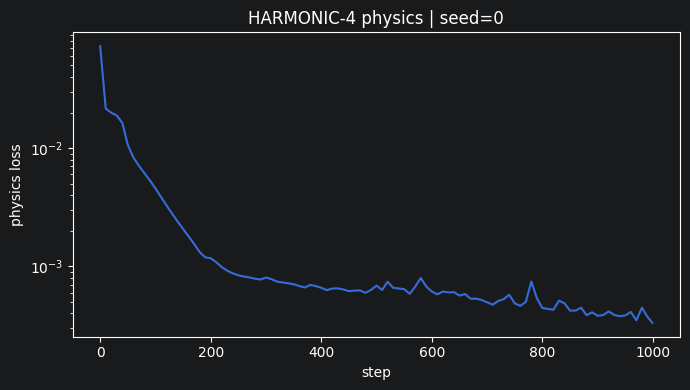

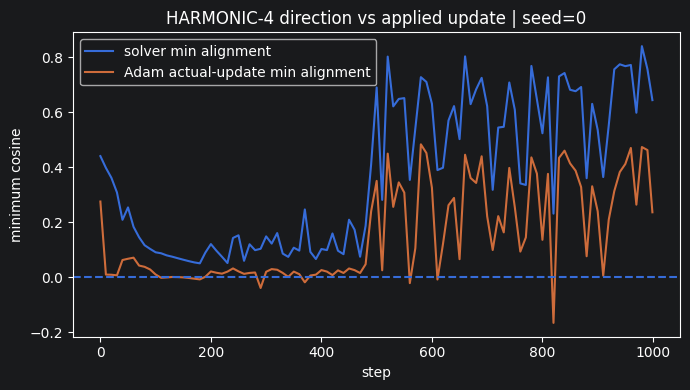

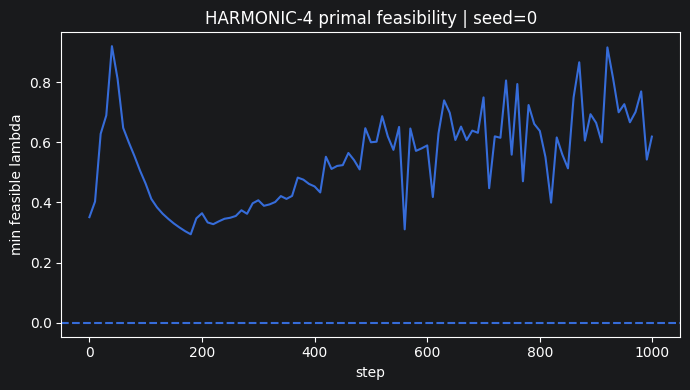

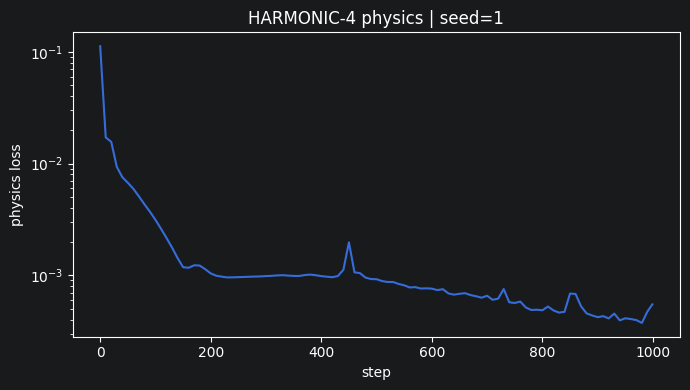

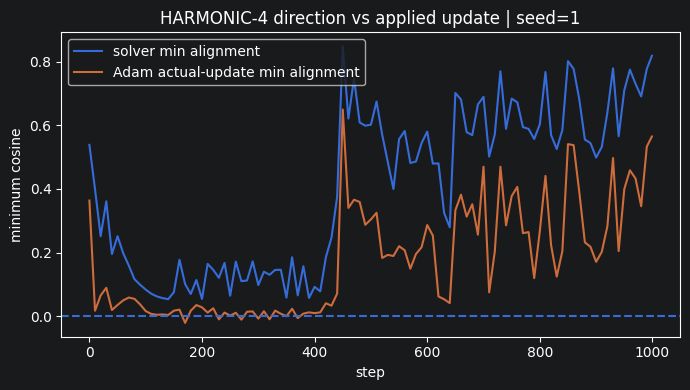

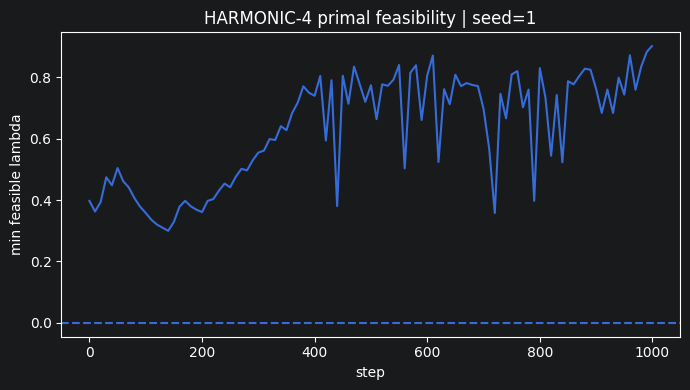

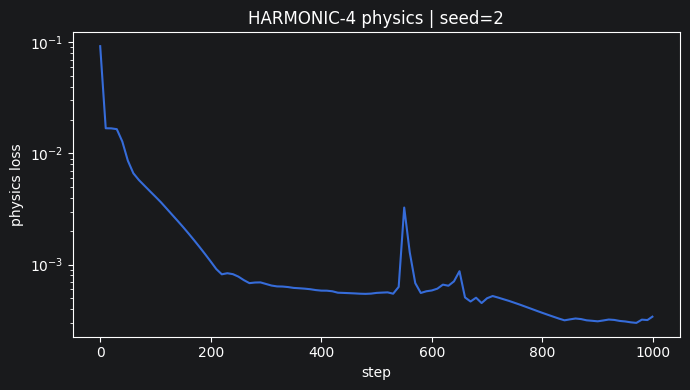

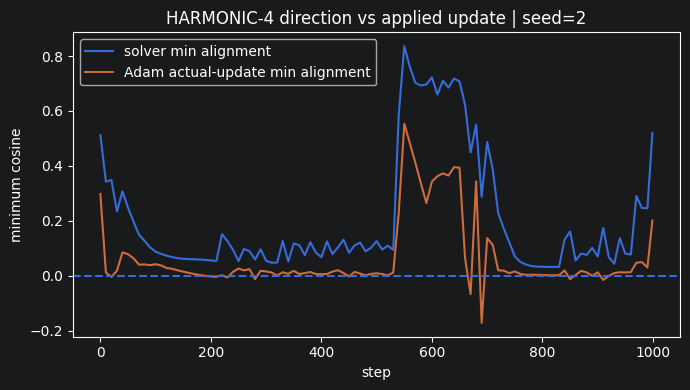

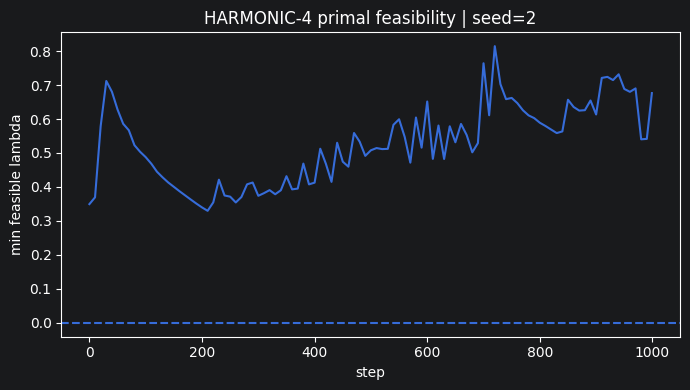

In [12]:
for seed in RUN_SEEDS:
    rs=sorted([r for r in histories if int(r['seed'])==seed],key=lambda r:int(r['step']))
    if not rs: continue
    steps=[int(r['step']) for r in rs]

    plt.figure(figsize=(7,4))
    plt.semilogy(steps,[float(r['physics']) for r in rs])
    plt.xlabel('step'); plt.ylabel('physics loss'); plt.title(f'HARMONIC-4 physics | seed={seed}')
    plt.tight_layout(); plt.savefig(AGG/f'seed_{seed}_physics.png',dpi=220,bbox_inches='tight'); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(steps,[float(r['min_harmonic_alignment']) for r in rs],label='solver min alignment')
    plt.plot(steps,[float(r['min_actual_update_alignment']) for r in rs],label='Adam actual-update min alignment')
    plt.axhline(0,linestyle='--'); plt.xlabel('step'); plt.ylabel('minimum cosine')
    plt.title(f'HARMONIC-4 direction vs applied update | seed={seed}')
    plt.legend(); plt.tight_layout(); plt.savefig(AGG/f'seed_{seed}_alignment.png',dpi=220,bbox_inches='tight'); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(steps,[float(r['min_feasible_lambda']) for r in rs])
    plt.axhline(0,linestyle='--'); plt.xlabel('step'); plt.ylabel('min feasible lambda')
    plt.title(f'HARMONIC-4 primal feasibility | seed={seed}')
    plt.tight_layout(); plt.savefig(AGG/f'seed_{seed}_feasibility.png',dpi=220,bbox_inches='tight'); plt.show()


## 跑完后优先上传这些文件

```text
aggregate/mean_std_summary.csv
aggregate/threshold_mean_std.csv
aggregate/pairwise_geometry_summary.csv
aggregate/harmonic_direction_alignment_summary.csv
aggregate/harmonic_feasibility_summary.csv
aggregate/actual_update_alignment_summary.csv
```

其中前两个直接进入现有横向性能表；后四个用于回答：

1. 原始 data ↔ physics 冲突是否仍存在；
2. HARMONIC common direction 是否始终 non-conflict；
3. common direction 是否始终位于 primal feasible cone；
4. 经过 Adam 后的真实 applied update 是否又破坏了这种性质。

如需进一步定位训练过程，再补：

```text
aggregate/all_metric_history.csv
aggregate/all_field_metrics.csv
aggregate/all_run_meta.csv
```


In [13]:
print(OUTPUT_ROOT.resolve())
print('Expected aggregate files:')
for name in [
    'mean_std_summary.csv','threshold_mean_std.csv','pairwise_geometry_summary.csv',
    'harmonic_direction_alignment_summary.csv','harmonic_feasibility_summary.csv',
    'actual_update_alignment_summary.csv','all_metric_history.csv','all_field_metrics.csv','all_run_meta.csv'
]:
    print(' -',name)


/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_harmonic4
Expected aggregate files:
 - mean_std_summary.csv
 - threshold_mean_std.csv
 - pairwise_geometry_summary.csv
 - harmonic_direction_alignment_summary.csv
 - harmonic_feasibility_summary.csv
 - actual_update_alignment_summary.csv
 - all_metric_history.csv
 - all_field_metrics.csv
 - all_run_meta.csv
